### Import Libraries

In [1]:
import pandas as pd
import numpy as np

### Loading data and selecting features

#### Import data 

In [2]:
#preserve indexes for correct matching
loan_data_inputs_train = pd.read_csv('loan_data_inputs_train.csv', index_col = 0) #use content of the first column as indexes
# loan_data_target_train = pd.read_csv('loan_data_targets_train.csv', index_col = 0, header = None) #don't import header for the df with targets
loan_data_target_train = pd.read_csv('loan_data_targets_train.csv', index_col = 0)
loan_data_inputs_test = pd.read_csv('loan_data_inputs_test.csv', index_col = 0)
loan_data_target_test = pd.read_csv('loan_data_targets_test.csv', index_col = 0)

#### Explore data 

In [3]:
loan_data_inputs_train.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
456615,456615,10588532,12470492,15000,15000,15000.0,36 months,8.90,476.30,A,...,0,0,0,1,0,0,0,0,0,0
451541,451541,11215587,13127755,8000,8000,8000.0,60 months,18.25,204.24,D,...,0,1,0,1,0,0,0,0,0,0
394474,394474,14218271,16270650,12150,12150,12100.0,60 months,18.92,314.65,D,...,0,1,0,1,0,0,0,0,0,0
110294,110294,6504869,8057011,10000,10000,10000.0,36 months,6.03,304.36,A,...,0,0,0,1,0,0,0,0,0,0
139343,139343,3929378,5022980,15825,15825,15825.0,36 months,12.12,526.53,B,...,0,0,0,1,0,0,0,0,0,0


In [4]:
loan_data_target_train.head()

,good_bad
456615,1
451541,1
394474,1
110294,1
139343,0


In [5]:
loan_data_inputs_train.shape

(373028, 326)

In [6]:
loan_data_target_train.shape

(373028, 1)

In [7]:
loan_data_inputs_test.shape

(93257, 326)

In [8]:
loan_data_target_test.shape

(93257, 1)

#### Building the PD model


##### Selecting features

In [9]:
# USe dummy variables only excluding the reference variables
loan_data_inputs_train.columns = loan_data_inputs_train.columns.str.replace(' : ', ':')
loan_data_inputs_train.columns = loan_data_inputs_train.columns.str.strip()

inputs_train_with_ref_cat = loan_data_inputs_train.loc[:, [

# Grade
'grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',

# Home ownership
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',

# Address state
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',

# Verification status
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',

# Purpose
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',

# Initial list status
'initial_list_status:f',
'initial_list_status:w',

# Term
'term:36',
'term:60',

# Employment length
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',

# Months since issue
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',

# Interest rate
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',

# Months since earliest credit line
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',

# Delinquencies
'delinq_2yrs:0',
'delinq_2yrs:1-3',
'delinq_2yrs:>=4',

# Inquiries
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',

# Open accounts
'open_acc:0',
'open_acc:1-3',
'open_acc:4-12',
'open_acc:13-17',
'open_acc:18-22',
'open_acc:23-25',
'open_acc:26-30',
'open_acc:>=31',

# Public records
'pub_rec:0-2',
'pub_rec:3-4',
'pub_rec:>=5',

# Total accounts
'total_acc:<=27',
'total_acc:28-51',
'total_acc:>=52',

# Accounts delinquent
'acc_now_delinq:0',
'acc_now_delinq:>=1',

# Revolving credit limit
'total_rev_hi_lim:<=5K',
'total_rev_hi_lim:5K-10K',
'total_rev_hi_lim:10K-20K',
'total_rev_hi_lim:20K-30K',
'total_rev_hi_lim:30K-40K',
'total_rev_hi_lim:40K-55K',
'total_rev_hi_lim:55K-95K',
'total_rev_hi_lim:>95K',

# Annual income
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',

# Debt to income
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',

# Months since last delinquency
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',

# Months since last record
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>86'

]]

In [10]:
# store the names of the reference category dummy variables in a list.
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'delinq_2yrs:>=4',
'inq_last_6mths:>6',
'open_acc:0',
'pub_rec:0-2',
'total_acc:<=27',
'acc_now_delinq:0',
'total_rev_hi_lim:<=5K',
'annual_inc:<20K',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

##### Remove reference categories

In [11]:
# From the dataframe with input variables, we drop the variables with variable names in the list with reference categories. 
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)  #axis 1 - column wise ie among column headers else it defaults to axis 0 - row wise 
inputs_train.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
456615,1,0,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
451541,0,0,0,1,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
394474,0,0,0,1,0,0,1,0,0,0,...,0,1,0,0,1,0,0,0,0,0
110294,1,0,0,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
139343,0,1,0,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0


### Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [13]:
#create instance of logistic reg class i.e model object
reg = LogisticRegression()
# reg = LogisticRegression(max_iter=1000) 

In [14]:
#make sure all rows are printed
pd.options.display.max_rows = None

In [15]:
#estimate the model by fitting(training) the inputs and the targets and store result in reg object
# inputs_train - all the independent dummy variables without the reference categories
# loan_data_targets_train - dependent variable i.e good bad indicator

reg.fit(inputs_train, loan_data_target_train) #model learns relationship between X and y

C:\Users\lkima\Documents\credit_risk_modelling\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
#get coefficients of the pd model 
# base risk when all variables are zero.
# It is the starting probability.

reg.intercept_ #gives intercept

array([-0.32172136])

In [17]:
#gives the coefficients in the order of the dependant var from inputs df 
#How much that variable increases or decreases the probability of default.

reg.coef_ 

array([[ 9.11648957e-01,  7.17320474e-01,  5.36324730e-01,
         3.61235953e-01,  2.09927099e-01,  5.93674585e-02,
         7.18718804e-02,  1.19428621e-01,  7.88126698e-02,
         9.53033338e-02,  8.89069503e-02,  1.01712023e-01,
         1.09777547e-01,  1.64644863e-01,  1.09209145e-01,
         2.26197023e-01,  2.98529802e-01,  2.48365580e-01,
         3.02079055e-01,  3.56214167e-01,  5.02224953e-01,
         1.07333307e-01,  5.16226750e-04,  2.73433519e-01,
         1.59422934e-01,  1.55845592e-01,  2.38237812e-01,
         5.57529202e-02,  8.01811507e-02,  1.18443296e-01,
         1.25866283e-01,  9.15247698e-02,  5.94206405e-02,
         1.27808646e-01,  1.11336671e+00,  9.20819540e-01,
         8.21879129e-01,  6.10539158e-01,  4.77892908e-01,
         2.31532857e-01, -2.52927623e-02,  9.92927829e-01,
         6.33611908e-01,  3.61719826e-01,  1.41715800e-01,
         8.17373526e-02,  4.63251084e-02,  8.94172598e-02,
         1.38403959e-01,  1.34288755e-01, -1.20445050e-0

In [18]:
# These coefficients tell us: How each variable affects default risk, Direction of impact, Strength of impact
# Positive coefficient: → Increases probability of being good (non-default)
# Negative coefficient: → Increases probability of default

In [19]:
# Connect coefficients to var names
feature_name = inputs_train.columns.values   #This line captures column names so you can map them back to their calculated coefficients.

In [20]:
#summary table df with feature names and corresponding coefficients
#final translated version of your model that humans can actually read.
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)   

# Creates a dataframe with a column titled 'Feature name' and row values contained in the 'feature_name' variable. Flips the array from a row to a column
summary_table['Coefficients'] = np.transpose(reg.coef_) #Transpose converts row → column.
# Creates a new column in the dataframe, called 'Coefficients', with row values the transposed coefficients from the 'LogisticRegression' object.

summary_table.index = summary_table.index + 1
# Increases the index of every row of the dataframe with 1. 
#By default, your DataFrame index starts at 0. This line shifts every row down by one (0 becomes 1, 1 becomes 2)

summary_table.loc[0] = ['Intercept', reg.intercept_[0]] 
#Now that index 0 is empty, you manually plug in the Intercept value.
# Assigns values of the row with index 0 of the dataframe.
#This is the base "log-odds" of someone not defaulting before you even look at their specific data (like their income or grade).

summary_table = summary_table.sort_index()
# Sorts the dataframe by index.
#This ensures the Intercept sits at the very top, followed by all your variables.

summary_table

,Feature name,Coefficients
0,Intercept,-0.321721
1,grade:A,0.911649
2,grade:B,0.717320
3,grade:C,0.536325
4,grade:D,0.361236
5,grade:E,0.209927
6,grade:F,0.059367
7,home_ownership:OWN,0.071872
8,home_ownership:MORTGAGE,0.119429
9,addr_state:NM_VA,0.078813


### Bulding a logistic regression model with P-values

Check statistical significance of a dummy variable

A p-value answers:
If this variable had NO real effect, what is the probability we would see this result by chance?
Small p-value → likely real effect
Large p-value → likely random noise
p < 0.05 → coefficient of var is statistically significant
p > 0.05 → coefficient not statistically significant

To be able to calculate the multivariate p values - alter the fit method from the logistic reg

In [21]:
# assess which var contribute to predicting borrower default and which one don't (statistical significance)
#It gives us proper multivariate p-values.

# P values for sklearn logistic regression.

# Class to display p-values for logistic regression in sklearn.

from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values:
    
    def __init__(self,*args,**kwargs):#,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs)#,**args)

    def fit(self,X,y):
        self.model.fit(X,y)
        
        #### Get p-values for the fitted model ####
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X) ## Fisher Information Matrix
        Cramer_Rao = np.linalg.inv(F_ij) ## Inverse Information Matrix
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates # z-score for eaach model coefficient
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores] ### two tailed test for p-values
        
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [22]:
# import statsmodels.api as sm

# # 1. Statsmodels doesn't automatically add the Intercept (Constant), so we must add it.
# # This creates a column of 1s so the math can calculate the 'baseline' risk.
# X_train_with_constant = sm.add_constant(inputs_train)

# # 2. Define and Fit the model (Logit is the statistical name for Logistic Regression)
# sm_model = sm.Logit(loan_data_target_train, X_train_with_constant)
# sm_result = sm_model.fit()

# # 3. The "Magic" Command
# print(sm_result.summary())

In [23]:
reg = LogisticRegression_with_p_values()
# We create an instance of an object from the newly created 'LogisticRegression_with_p_values()' class.

In [24]:
reg.fit(inputs_train, loan_data_target_train)
# Estimates the coefficients of the object from the 'LogisticRegression' class
# with inputs (independent variables) contained in the first dataframe
# and targets (dependent variables) contained in the second dataframe.

C:\Users\lkima\Documents\credit_risk_modelling\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [25]:
# Same as above.
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.321721
1,grade:A,0.911649
2,grade:B,0.717320
3,grade:C,0.536325
4,grade:D,0.361236
5,grade:E,0.209927
6,grade:F,0.059367
7,home_ownership:OWN,0.071872
8,home_ownership:MORTGAGE,0.119429
9,addr_state:NM_VA,0.078813


In [26]:
# This is a list.
p_values = reg.p_values
# We take the result of the newly added method 'p_values' and store it in a variable 'p_values'.

In [27]:
# Add the intercept for completeness.
p_values = np.append(np.nan, np.array(p_values))
# We add the value 'NaN' in the beginning of the variable with p-values.

In [28]:
summary_table['p_values'] = p_values
# In the 'summary_table' dataframe, we add a new column, called 'p_values', containing the values from the 'p_values' variable.

In [29]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.321721,NaN
1,grade:A,0.911649,6.151087e-23
2,grade:B,0.717320,6.747789e-31
3,grade:C,0.536325,1.452602e-20
4,grade:D,0.361236,4.706239e-11
5,grade:E,0.209927,2.038303e-05
6,grade:F,0.059367,2.470670e-01
7,home_ownership:OWN,0.071872,3.409690e-04
8,home_ownership:MORTGAGE,0.119429,5.592318e-21
9,addr_state:NM_VA,0.078813,1.396556e-02


Retain variables whose coefficients are statistically significant i.e p < 0.05

If ALL dummies insignificant → remove entire variable
If one or few dummy significant → keep entire variable

#### Remove statistically insignificant variables and fit the model again

In [30]:
# We are going to remove some features, the coefficients for all or almost all of the dummy variables for which,
# are not tatistically significant.

# We do that by specifying another list of dummy variables as reference categories, and a list of variables to remove.
# Then, we are going to drop the two datasets from the original list of dummy variables.

# Variables
inputs_train_with_ref_cat = loan_data_inputs_train.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>86',
]]

In [31]:
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'annual_inc:<20K',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [32]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)
inputs_train.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
456615,1,0,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
451541,0,0,0,1,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
394474,0,0,0,1,0,0,1,0,0,0,...,0,1,0,0,1,0,0,0,0,0
110294,1,0,0,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
139343,0,1,0,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0


In [33]:
# Here we run a new model.
reg2 = LogisticRegression_with_p_values()
reg2.fit(inputs_train, loan_data_target_train)

C:\Users\lkima\Documents\credit_risk_modelling\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [34]:
feature_name = inputs_train.columns.values

In [35]:
# Same as above.
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg2.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.791083
1,grade:A,1.027107
2,grade:B,0.866439
3,grade:C,0.692273
4,grade:D,0.514298
5,grade:E,0.347651
6,grade:F,0.188875
7,home_ownership:OWN,0.072958
8,home_ownership:MORTGAGE,0.117042
9,addr_state:NM_VA,0.057471


In [36]:
# We add the 'p_values' here, just as we did before.
p_values = reg2.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table
# Here we get the results for our final PD model.

,Feature name,Coefficients,p_values
0,Intercept,-0.791083,NaN
1,grade:A,1.027107,1.162773e-28
2,grade:B,0.866439,5.723867e-46
3,grade:C,0.692273,1.110159e-34
4,grade:D,0.514298,5.620296e-22
5,grade:E,0.347651,1.830033e-13
6,grade:F,0.188875,1.191602e-04
7,home_ownership:OWN,0.072958,2.666980e-04
8,home_ownership:MORTGAGE,0.117042,2.291496e-20
9,addr_state:NM_VA,0.057471,7.392551e-02


#### Interpreting coefficients of a PD model

Increasing coefficients magnitude - increasing odds of being good
Direct comparisons - betweeen categories from one and the same original independent var only (mutual exclusivity)

In [37]:
import pickle

In [38]:
pickle.dump(reg2, open('pd_model.sav', 'wb'))
# Here we export our model to a 'SAV' file with file name 'pd_model.sav'.

### PD model validation (Test)

Out-of-sample validation (test)

In [39]:
# USe dummy variables only excluding the reference variables
loan_data_inputs_test.columns = loan_data_inputs_test.columns.str.replace(' : ', ':')
loan_data_inputs_test.columns = loan_data_inputs_test.columns.str.strip()

# Here, from the dataframe with inputs for testing, we keep the same variables that we used in our final PD model.
inputs_test_with_ref_cat = loan_data_inputs_test.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>86',
]]

In [40]:
# And here, in the list below, we keep the variable names for the reference categories,
# only for the variables we used in our final PD model.
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'annual_inc:<20K',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [41]:
inputs_test = inputs_test_with_ref_cat.drop(ref_categories, axis = 1)
inputs_test.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
395346,0,0,1,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
376583,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
297790,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
47347,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
446772,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0


#### Use the model to estimate the probability of default of each observation from the test data 

In [42]:
y_hat_test = reg2.model.predict(inputs_test)  #cut-off of 0.5 is applied by default in the background
# Calculates the predicted values for the dependent variable (targets)
# based on the values of the independent variables (inputs) supplied as an argument.

In [43]:
y_hat_test
# This is an array of predicted discrete classess (in this case, 0s and 1s).

array([1, 1, 1, ..., 1, 1, 1], shape=(93257,))

##### (.predict()) gave you a simple "Yes" or "No," .predict_proba() gives you the exact percentage of risk for every borrower.

In [44]:
y_hat_test_proba = reg2.model.predict_proba(inputs_test) #obtains the raw predicted probability of each observation
# Calculates the predicted probability values for the dependent variable (targets)
# based on the values of the independent variables (inputs) supplied as an argument.

In [45]:
y_hat_test_proba
# This is an array of arrays of predicted class probabilities for all classes.
# In this case, the first value of every sub-array is the probability for the observation to belong to the first class, i.e. 0,
# and the second value is the probability for the observation to belong to the first class, i.e. 1.
#Column 0: Probability of the borrower being "Bad" (Default).
#Column 1: Probability of the borrower being "Good" (Repayment).

array([[0.10837957, 0.89162043],
       [0.02591285, 0.97408715],
       [0.0937232 , 0.9062768 ],
       ...,
       [0.20885116, 0.79114884],
       [0.06966508, 0.93033492],
       [0.1566464 , 0.8433536 ]], shape=(93257, 2))

In [46]:
y_hat_test_proba[:][:,1] 

#isolate the "Probability of being Good" from the model's output.
#array containing probability of being a good borrower
# Here we take all the arrays in the array, and from each array, we take all rows, and only the element with index 1,
# that is, the second element.
# In other words, we take only the probabilities for being 1.

array([0.89162043, 0.97408715, 0.9062768 , ..., 0.79114884, 0.93033492,
       0.8433536 ], shape=(93257,))

In [47]:
y_hat_test_proba = y_hat_test_proba[: , 1]
# We store these probabilities in a variable.

In [48]:
y_hat_test_proba
# This variable contains an array of probabilities of being 1.
# clean list of "Good" probabilities that you can compare against the actual results to see if your model was right.

array([0.89162043, 0.97408715, 0.9062768 , ..., 0.79114884, 0.93033492,
       0.8433536 ], shape=(93257,))

In [49]:
loan_data_target_test_temp = loan_data_target_test

In [50]:
loan_data_target_test_temp.reset_index(drop = True, inplace = True)
# We reset the index of a dataframe and update current df 

In [51]:
df_actual_predicted_probs = pd.concat([loan_data_target_test_temp, pd.DataFrame(y_hat_test_proba)], axis = 1)
# Concatenates two dataframes.

In [52]:
df_actual_predicted_probs.shape

(93257, 2)

In [53]:
df_actual_predicted_probs.columns = ['loan_data_target_test', 'y_hat_test_proba']

In [54]:
df_actual_predicted_probs.index = loan_data_inputs_test.index
# Makes the index of one dataframe equal to the index of another dataframe.

In [55]:
df_actual_predicted_probs.head()

,loan_data_target_test,y_hat_test_proba
395346,1,0.891620
376583,1,0.974087
297790,1,0.906277
47347,1,0.907128
446772,0,0.888159


The 'predict' method returns predicted class and the 'predict_proba' method returns all probabilities to belong to each of the classess

### Accuracy and Area under the curve

In [56]:
tr = 0.9 
#cut off threshold
#If a person's probability of being a good borrower isn't at least 90%, we aren't going to trust them.

# We create a new column with an indicator,
# where every observation that has predicted probability greater than the threshold has a value of 1,
# and every observation that has predicted probability lower than the threshold has a value of 0.

df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

#### Confusion matrix

- The "Nightmare Scenario": How many people you approved who actually defaulted. (False Positives)

In [57]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], 
            rownames = ['Actual'], colnames = ['Predicted'])
# Creates a cross-table where the actual values are displayed by rows and the predicted values by columns.
# This table is known as a Confusion Matrix.

Predicted,0,1
Actual,,
0,7312,2882
1,35625,47438


In [58]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], 
            rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]
# Here we divide each value of the table by the total number of observations,
# thus getting percentages, or, rates.

Predicted,0,1
Actual,,
0,0.078407,0.030904
1,0.382009,0.508680


#### Accuracy

Sum of true positives and true negatives, divided by the total number of observations

In [59]:
(pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], 
             rownames = ['Actual'], colnames = ['Predicted'])
             / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], 
                         rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]
# Here we calculate Accuracy of the model, which is the sum of the minor diagonal rates.

np.float64(0.587087296395981)

#### ROC Curve
Rate of true positive predictions curve - receiver operating characteristic curve (ROC)

Plots the true positives as a func of false positives

The ROC Curve shows you how the model performs at every possible threshold at once.

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

In [61]:
roc_curve(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test_proba'])
# Returns the Receiver Operating Characteristic (ROC) Curve from a set of actual values and their predicted probabilities.
# As a result, we get three arrays: the false positive rates, the true positive rates, and the thresholds.

#array 1 - false positive rate
#array 2 - true positive rate
#array 3 - thresholds

(array([0.        , 0.        , 0.        , ..., 0.99980381, 0.99980381,
        1.        ], shape=(17370,)),
 array([0.00000000e+00, 1.20390547e-05, 4.57484078e-04, ...,
        9.99975922e-01, 1.00000000e+00, 1.00000000e+00], shape=(17370,)),
 array([       inf, 0.99243673, 0.98958921, ..., 0.49402799, 0.46761522,
        0.45301264], shape=(17370,)))

In [62]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test_proba'])
# Here we store each of the three arrays in a separate variable. 
# fpr - false positive rate
# tpr - true positive rate 

# true positive rate shows as a func of the false positive rate 

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Text(0.5, 1.0, 'ROC curve')

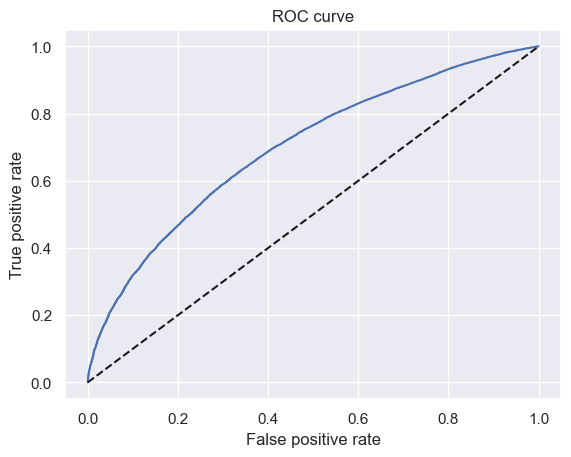

In [64]:
plt.plot(fpr, tpr)
# We plot the false positive rate along the x-axis and the true positive rate along the y-axis,
# thus plotting the ROC curve.
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
# We plot a seconary diagonal line, with dashed line style and black color.
plt.xlabel('False positive rate')
# We name the x-axis "False positive rate".
plt.ylabel('True positive rate')
# We name the x-axis "True positive rate".
plt.title('ROC curve')
# We name the graph "ROC curve".

If I gave the model two random people—one who is going to pay back and one who is going to default—the model would correctly identify the better borrower about 70-75% of the time.

#### Area Under the Curve (AUC)

Overall measure of how good the classification model is.

Each point from the curve rep a confusion matrix

AUC as a single number that tells you: "How good is this model at sorting people into 'Good' and 'Bad' piles?"

In [65]:
AUROC = roc_auc_score(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test_proba'])
# Calculates the Area Under the Receiver Operating Characteristic Curve (AUROC)
# from a set of actual values and their predicted probabilities.
AUROC

0.6993233807977492

Scale for interpretation for area under the curve

- Bad 50 - 60%
- Poor 60 - 70%
- Fair 70 - 80%
- Good 80 -90%
- Excellent 90 - 100%

Accuracy is "Threshold-Dependent." It changes if you change your tr = 0.9 to tr = 0.5. It's like judging a student's intelligence based on one specific, very hard test.

AUC is "Threshold-Independent." It measures the model's performance across all possible thresholds. It tells you how well the model separates the two groups, regardless of how strict or relaxed you decide to be as a manager.

### PD model Evaluation

### Gini and Kolmogorov-Smirnov

Helps know to what extent the outcome of interest can be explained by the available info

Measure how well the model separates good vs bad borrowers.

Plot cumulative proportion of defaulted as a function of cumulative proportion of all borrowers

Gini coefficient is the percentage of the area above the secondary diagonal line enclosed between the concave curve and the secondary diagonal line
 - the greater the are the better the model

KS shows to what extent the model separates the actual good borrowers from the actual bad borrowers
 - max diff of the cumulative distribution of good and bad borrowers with respect to the predicted probabilities
 - greater diff better model

Gini tells you how reliable the model's ranking is.

KS tells you how strong the separation between Good and Bad is at its best point.

In [66]:
df_actual_predicted_probs = df_actual_predicted_probs.sort_values('y_hat_test_proba')
# Sorts a dataframe by the values of a specific column.

In [67]:
df_actual_predicted_probs.head()

,loan_data_target_test,y_hat_test_proba,y_hat_test
42398,0,0.453013,0
29671,0,0.460434,0
42341,1,0.467615,0
41663,1,0.471094,0
12508,0,0.494028,0


In [68]:
df_actual_predicted_probs.tail()

,loan_data_target_test,y_hat_test_proba,y_hat_test
231463,1,0.991459,1
261086,1,0.991923,1
293709,1,0.992000,1
247902,1,0.992218,1
251159,1,0.992437,1


In [69]:
df_actual_predicted_probs = df_actual_predicted_probs.reset_index()
# We reset the index of a dataframe and overwrite it.

In [70]:
df_actual_predicted_probs.head()

,index,loan_data_target_test,y_hat_test_proba,y_hat_test
0,42398,0,0.453013,0
1,29671,0,0.460434,0
2,42341,1,0.467615,0
3,41663,1,0.471094,0
4,12508,0,0.494028,0


#### Cumulative Accuracy Profile (CAP)

The CAP curve shows how quickly you "capture" those bad borrowers as you work your way through the line.

CAP Curve tells you about Efficiency. It’s about how quickly you can "filter out" the bad borrowers from the total population.

In [71]:
df_actual_predicted_probs['Cumulative N Population'] = df_actual_predicted_probs.index + 1
# We calculate the cumulative number of all observations.
# We use the new index for that. Since indexing in python starts from 0, we add 1 to each index.

df_actual_predicted_probs['Cumulative N Good'] = df_actual_predicted_probs['loan_data_target_test'].cumsum()
# We calculate cumulative number of 'good', which is the cumulative sum of the column with actual observations

df_actual_predicted_probs['Cumulative N Bad'] = df_actual_predicted_probs['Cumulative N Population'] - df_actual_predicted_probs['loan_data_target_test'].cumsum()
# We calculate cumulative number of 'bad', which is
# the difference between the cumulative number of all observations and cumulative number of 'good' for each row.

In [72]:
df_actual_predicted_probs.head()

,index,loan_data_target_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad
0,42398,0,0.453013,0,1,0,1
1,29671,0,0.460434,0,2,0,2
2,42341,1,0.467615,0,3,1,2
3,41663,1,0.471094,0,4,2,2
4,12508,0,0.494028,0,5,2,3


Cumulative N Population 
- Total Sample Size" at that specific point in your data.
- It represents the total number of people the model has "seen" so far.
  
Cumulative N Good
- It counts how many "Good" borrowers you have collected up to that row.

Cumulative N Bad
- t takes the Total Population and subtracts the Good borrowers. Whatever is left over must be the "Bad" borrowers (the 0s).

#### Cumulative proportions

Cumulative proportions are the numbers divided by their own totals - for distibution plots

In [73]:
df_actual_predicted_probs['Cumulative Perc Population'] = df_actual_predicted_probs['Cumulative N Population'] / (df_actual_predicted_probs.shape[0])
# We calculate the cumulative percentage of all observations.
df_actual_predicted_probs['Cumulative Perc Good'] = df_actual_predicted_probs['Cumulative N Good'] / df_actual_predicted_probs['loan_data_target_test'].sum()
# We calculate cumulative percentage of 'good'.
df_actual_predicted_probs['Cumulative Perc Bad'] = df_actual_predicted_probs['Cumulative N Bad'] / (df_actual_predicted_probs.shape[0] - df_actual_predicted_probs['loan_data_target_test'].sum())
# We calculate the cumulative percentage of 'bad'.

In [74]:
df_actual_predicted_probs.head()

,index,loan_data_target_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
0,42398,0,0.453013,0,1,0,1,0.000011,0.000000,0.000098
1,29671,0,0.460434,0,2,0,2,0.000021,0.000000,0.000196
2,42341,1,0.467615,0,3,1,2,0.000032,0.000012,0.000196
3,41663,1,0.471094,0,4,2,2,0.000043,0.000024,0.000196
4,12508,0,0.494028,0,5,2,3,0.000054,0.000024,0.000294


In [75]:
df_actual_predicted_probs.tail()

,index,loan_data_target_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
93252,231463,1,0.991459,1,93253,83059,10194,0.999957,0.999952,1.0
93253,261086,1,0.991923,1,93254,83060,10194,0.999968,0.999964,1.0
93254,293709,1,0.992000,1,93255,83061,10194,0.999979,0.999976,1.0
93255,247902,1,0.992218,1,93256,83062,10194,0.999989,0.999988,1.0
93256,251159,1,0.992437,1,93257,83063,10194,1.000000,1.000000,1.0


Text(0.5, 1.0, 'Cumulative Accuracy Profile Curve - Gini')

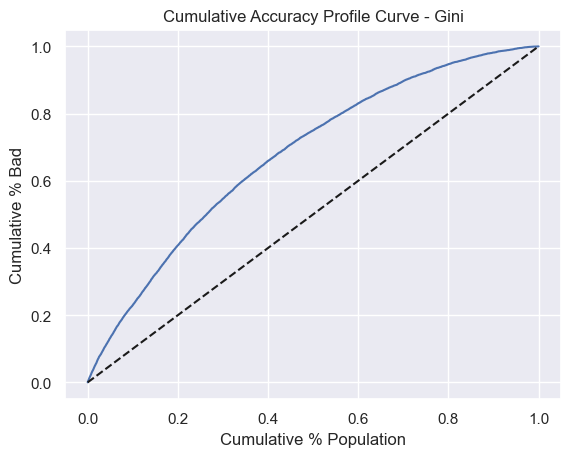

In [76]:
# Plot Gini
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Bad'])
# We plot the cumulative percentage of all along the x-axis and the cumulative percentage 'good' along the y-axis,
# thus plotting the Gini curve.
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Population'], linestyle = '--', color = 'k')
# We plot a seconary diagonal line, with dashed line style and black color.
plt.xlabel('Cumulative % Population')
# We name the x-axis "Cumulative % Population".
plt.ylabel('Cumulative % Bad')
# We name the y-axis "Cumulative % Bad".
plt.title('Cumulative Accuracy Profile Curve - Gini')
# We name the graph "Gini".

If we only looked at the top 20% of your riskiest applicants, your model would catch 40% of all the people who were going to default.

At that same 20% mark, a random guess would only have caught 20% of the defaults.

The "Win": Your model is exactly twice as efficient as a random guess at that specific point!

Gini Coefficient is basically the "size" of the gap between your blue curve and that dashed diagonal line.

- If the blue line was closer to the diagonal: Your Gini would be low (maybe 0.2), meaning the model isn't very helpful.
- Since your blue line has a healthy "bow": Your Gini is likely in the 0.40 to 0.50 range. In the banking industry, this is considered a solid, reliable model. It shows a clear ability to separate risk without being "too good to be true."

Cumulative Perc Population 
- "How much of our customer base have we looked at so far?"

Cumulative Perc Good & Cumulative Perc Bad
- Of all the people who will ever default in this group, what percentage have we caught already?

The "Law of Diminishing Returns"

Notice how the blue curve is very steep at the beginning and then starts to flatten out as it reaches the top right?

The Steep Part: This is where your model is most powerful. It’s identifying the "obvious" bad borrowers.

The Flat Part: This is where the risk is "murky." To catch the last 5% of bad borrowers, you have to look through a huge portion of your population because they look very similar to the good borrowers.

In [77]:
Gini = AUROC * 2 - 1
# Here we calculate Gini from AUROC.
Gini

0.3986467615954985

- "We are 40% more efficient at ranking customers than our competitors who guess."
- model is 40% better at ranking borrowers than if you were just guessing randomly.
- we use Gini to decide if a model is "Strong" enough to be used
  
Gini Score
- < 0.30, Weak: The model is barely better than a coin flip. Don't use it.
- 0.30 - 0.45,"Fair: Good for a first attempt, but could be improved with more data."
- 0.45 - 0.60,"Strong: This is the ""Industry Standard"" for most credit cards and personal loans."
- 0.60 - 0.75,Excellent: Very high predictive power.
- greater than 0.80,"Suspicious: Likely ""Overfitting"" or using data the bank wouldn't actually have."

Text(0.5, 1.0, 'Kolmogorov-Smirnov')

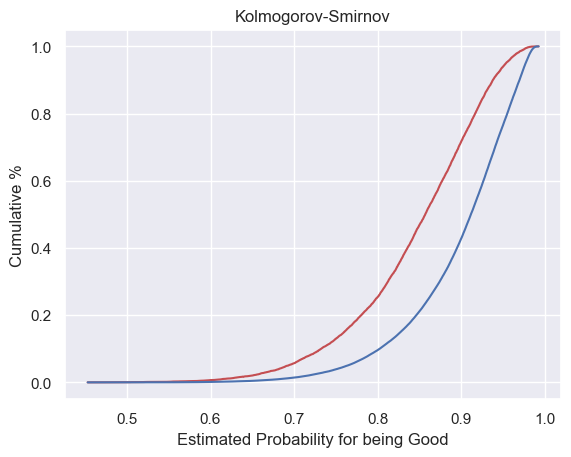

In [78]:
# Plot KS
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Bad'], color = 'r')
# We plot the predicted (estimated) probabilities along the x-axis and the cumulative percentage 'bad' along the y-axis,
# colored in red.
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Good'], color = 'b')
# We plot the predicted (estimated) probabilities along the x-axis and the cumulative percentage 'good' along the y-axis,
# colored in red.
plt.xlabel('Estimated Probability for being Good')
# We name the x-axis "Estimated Probability for being Good".
plt.ylabel('Cumulative %')
# We name the y-axis "Cumulative %".
plt.title('Kolmogorov-Smirnov')
# We name the graph "Kolmogorov-Smirnov".

the KS plot is about the "width of the gap" between your Good and Bad borrowers.

the Red Line to shoot up very quickly. This means most of the "Bad" people have very low "Goodness" scores (they are caught early).

the Blue Line to stay low for as long as possible. This means the "Good" people are mostly concentrated at the high end of your scoring scale.

In [79]:
KS = max(df_actual_predicted_probs['Cumulative Perc Bad'] - df_actual_predicted_probs['Cumulative Perc Good'])
# We calculate KS from the data. It is the maximum of the difference between the cumulative percentage of 'bad'
# and the cumulative percentage of 'good'.
KS

0.2915356769921957

"We have a 29% 'safety gap' to protect us from losses." - 0.29 (29%) is your "Efficiency Rating." It tells the bank how much "breathing room" it has to make a profit before it starts losing money to defaults.

KS Score,Rating,Meaning
- < 0.20,Weak,The model is struggling to separate risk.
- 0.20 - 0.40,Good / Acceptable,"(You are here!) This is a standard, healthy model for retail lending."
- 0.40 - 0.50,Strong,Excellent separation power.
- greater than 0.60,Suspicious,"The model might be ""too good""—check for data leaks!"

### Applying the PD model

Calculating pd of individual accounts


In [80]:
pd.options.display.max_columns = None
# Sets the pandas dataframe options to display all columns/ rows.

In [81]:
inputs_test_with_ref_cat.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:RENT_OTHER_NONE_ANY,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:ND_NE_IA_NV_FL_HI_AL,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:educ__sm_b__wedd__ren_en__mov__house,purpose:credit_card,purpose:debt_consolidation,purpose:oth__med__vacation,purpose:major_purch__car__home_impr,initial_list_status:f,initial_list_status:w,term:36,term:60,emp_length:0,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,mths_since_issue_d:<38,mths_since_issue_d:38-39,mths_since_issue_d:40-41,mths_since_issue_d:42-48,mths_since_issue_d:49-52,mths_since_issue_d:53-64,mths_since_issue_d:65-84,mths_since_issue_d:>84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,mths_since_earliest_cr_line:<140,mths_since_earliest_cr_line:141-164,mths_since_earliest_cr_line:165-247,mths_since_earliest_cr_line:248-270,mths_since_earliest_cr_line:271-352,mths_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,inq_last_6mths:>6,acc_now_delinq:0,acc_now_delinq:>=1,annual_inc:<20K,annual_inc:20K-30K,annual_inc:30K-40K,annual_inc:40K-50K,annual_inc:50K-60K,annual_inc:60K-70K,annual_inc:70K-80K,annual_inc:80K-90K,annual_inc:90K-100K,annual_inc:100K-120K,annual_inc:120K-140K,annual_inc:>140K,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_delinq:Missing,mths_since_last_delinq:0-3,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
395346,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
376583,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
297790,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
47347,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
446772,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0


In [82]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.791083,NaN
1,grade:A,1.027107,1.162773e-28
2,grade:B,0.866439,5.723867e-46
3,grade:C,0.692273,1.110159e-34
4,grade:D,0.514298,5.620296e-22
5,grade:E,0.347651,1.830033e-13
6,grade:F,0.188875,1.191602e-04
7,home_ownership:OWN,0.072958,2.666980e-04
8,home_ownership:MORTGAGE,0.117042,2.291496e-20
9,addr_state:NM_VA,0.057471,7.392551e-02


In [83]:
y_hat_test_proba

array([0.89162043, 0.97408715, 0.9062768 , ..., 0.79114884, 0.93033492,
       0.8433536 ], shape=(93257,))

#### Creating a scorecard


In [84]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.791083,NaN
1,grade:A,1.027107,1.162773e-28
2,grade:B,0.866439,5.723867e-46
3,grade:C,0.692273,1.110159e-34
4,grade:D,0.514298,5.620296e-22
5,grade:E,0.347651,1.830033e-13
6,grade:F,0.188875,1.191602e-04
7,home_ownership:OWN,0.072958,2.666980e-04
8,home_ownership:MORTGAGE,0.117042,2.291496e-20
9,addr_state:NM_VA,0.057471,7.392551e-02


In [85]:
ref_categories

['grade:G',
 'home_ownership:RENT_OTHER_NONE_ANY',
 'addr_state:ND_NE_IA_NV_FL_HI_AL',
 'verification_status:Verified',
 'purpose:educ__sm_b__wedd__ren_en__mov__house',
 'initial_list_status:f',
 'term:60',
 'emp_length:0',
 'mths_since_issue_d:>84',
 'int_rate:>20.281',
 'mths_since_earliest_cr_line:<140',
 'inq_last_6mths:>6',
 'acc_now_delinq:0',
 'annual_inc:<20K',
 'dti:>35',
 'mths_since_last_delinq:0-3',
 'mths_since_last_record:0-2']

In [86]:
df_ref_categories = pd.DataFrame(ref_categories, columns = ['Feature name'])
# We create a new dataframe with one column. Its values are the values from the 'reference_categories' list.
# We name it 'Feature name'.
df_ref_categories['Coefficients'] = 0
# We create a second column, called 'Coefficients', which contains only 0 values.
df_ref_categories['p_values'] = np.nan
# We create a third column, called 'p_values', with contains only NaN values.
df_ref_categories

,Feature name,Coefficients,p_values
0,grade:G,0,NaN
1,home_ownership:RENT_OTHER_NONE_ANY,0,NaN
2,addr_state:ND_NE_IA_NV_FL_HI_AL,0,NaN
3,verification_status:Verified,0,NaN
4,purpose:educ__sm_b__wedd__ren_en__mov__house,0,NaN
5,initial_list_status:f,0,NaN
6,term:60,0,NaN
7,emp_length:0,0,NaN
8,mths_since_issue_d:>84,0,NaN
9,int_rate:>20.281,0,NaN


In [87]:
df_scorecard = pd.concat([summary_table, df_ref_categories])
# Concatenates two dataframes.
df_scorecard = df_scorecard.reset_index()
# We reset the index of a dataframe.
df_scorecard

,index,Feature name,Coefficients,p_values
0,0,Intercept,-0.791083,NaN
1,1,grade:A,1.027107,1.162773e-28
2,2,grade:B,0.866439,5.723867e-46
3,3,grade:C,0.692273,1.110159e-34
4,4,grade:D,0.514298,5.620296e-22
5,5,grade:E,0.347651,1.830033e-13
6,6,grade:F,0.188875,1.191602e-04
7,7,home_ownership:OWN,0.072958,2.666980e-04
8,8,home_ownership:MORTGAGE,0.117042,2.291496e-20
9,9,addr_state:NM_VA,0.057471,7.392551e-02


In [88]:
df_scorecard['Original feature name'] = df_scorecard['Feature name'].str.split(':').str[0]
# We create a new column, called 'Original feature name', which contains the value of the 'Feature name' column,
# up to the column symbol.
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name
0,0,Intercept,-0.791083,NaN,Intercept
1,1,grade:A,1.027107,1.162773e-28,grade
2,2,grade:B,0.866439,5.723867e-46,grade
3,3,grade:C,0.692273,1.110159e-34,grade
4,4,grade:D,0.514298,5.620296e-22,grade
5,5,grade:E,0.347651,1.830033e-13,grade
6,6,grade:F,0.188875,1.191602e-04,grade
7,7,home_ownership:OWN,0.072958,2.666980e-04,home_ownership
8,8,home_ownership:MORTGAGE,0.117042,2.291496e-20,home_ownership
9,9,addr_state:NM_VA,0.057471,7.392551e-02,addr_state


In [89]:
#define the scorecard range
#high coefficients = high credit worthiness 
min_score = 300
max_score = 850

#Positive Coefficient: If this number goes up, the credit score goes up. (Example: A higher salary adds points to your score).
#Negative Coefficient: If this number goes up, the credit score goes down. (Example: Having 10 late payments subtracts points from your score).

In [90]:
df_scorecard.groupby('Original feature name')['Coefficients'].min()
# Groups the data by the values of the 'Original feature name' column.
# Aggregates the data in the 'Coefficients' column, calculating their minimum.

Original feature name
Intercept                     -0.791083
acc_now_delinq                 0.000000
addr_state                     0.000000
annual_inc                    -0.117156
dti                           -0.132105
emp_length                     0.000000
grade                          0.000000
home_ownership                 0.000000
initial_list_status            0.000000
inq_last_6mths                 0.000000
int_rate                       0.000000
mths_since_earliest_cr_line    0.000000
mths_since_issue_d            -0.050746
mths_since_last_delinq         0.000000
mths_since_last_record         0.000000
purpose                        0.000000
term                           0.000000
verification_status           -0.000991
Name: Coefficients, dtype: float64

In [91]:
min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()
# Up to the 'min()' method everything is the same as in te line above.
# Then, we aggregate further and sum all the minimum values.
min_sum_coef

np.float64(-1.0920812591886424)

In [92]:

df_scorecard.groupby('Original feature name')['Coefficients'].max()
# Groups the data by the values of the 'Original feature name' column.
# Aggregates the data in the 'Coefficients' column, calculating their maximum.

Original feature name
Intercept                     -0.791083
acc_now_delinq                 0.171933
addr_state                     0.483812
annual_inc                     0.487459
dti                            0.235175
emp_length                     0.127912
grade                          1.027107
home_ownership                 0.117042
initial_list_status            0.057397
inq_last_6mths                 0.372079
int_rate                       1.032490
mths_since_earliest_cr_line    0.125008
mths_since_issue_d             1.087614
mths_since_last_delinq         0.197426
mths_since_last_record         0.399625
purpose                        0.299656
term                           0.077356
verification_status            0.099518
Name: Coefficients, dtype: float64

In [93]:
max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()
# Up to the 'min()' method everything is the same as in te line above.
# Then, we aggregate further and sum all the maximum values.
max_sum_coef

np.float64(5.607527141557313)

##### Scaling the Weights
- This line converts raw mathematical "importance" (coefficients) into a proportional number of points on your 300–850 scale.

In [94]:
df_scorecard['Score - Calculation'] = df_scorecard['Coefficients'] * (max_score - min_score) / (max_sum_coef - min_sum_coef)
# We multiply the value of the 'Coefficients' column by the ration of the differences between
# maximum score and minimum score and maximum sum of coefficients and minimum sum of cefficients.
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-0.791083,NaN,Intercept,-64.943427
1,1,grade:A,1.027107,1.162773e-28,grade,84.319649
2,2,grade:B,0.866439,5.723867e-46,grade,71.129787
3,3,grade:C,0.692273,1.110159e-34,grade,56.831686
4,4,grade:D,0.514298,5.620296e-22,grade,42.220936
5,5,grade:E,0.347651,1.830033e-13,grade,28.540164
6,6,grade:F,0.188875,1.191602e-04,grade,15.505570
7,7,home_ownership:OWN,0.072958,2.666980e-04,home_ownership,5.989477
8,8,home_ownership:MORTGAGE,0.117042,2.291496e-20,home_ownership,9.608489
9,9,addr_state:NM_VA,0.057471,7.392551e-02,addr_state,4.718031


##### Setting the Starting Point
- This line adjusts the "Base Score" (the Intercept) so that even the riskiest possible borrower still starts at your minimum of 300 points.

In [95]:
df_scorecard['Score - Calculation'][0] = ((df_scorecard['Coefficients'][0] - min_sum_coef) / (max_sum_coef - min_sum_coef)) * (max_score - min_score) + min_score
# We divide the difference of the value of the 'Coefficients' column and the minimum sum of coefficients by
# the difference of the maximum sum of coefficients and the minimum sum of coefficients.
# Then, we multiply that by the difference between the maximum score and the minimum score.
# Then, we add minimum score. 
df_scorecard

C:\Users\lkima\AppData\Local\Temp\ipykernel_23716\1410049194.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scorecard['Score - Calculation'][0] = ((df_scorecard['Coefficients'][0] - min_sum_coef) / (max_sum_coef - min_sum_coef)) * (max_score - min_score) + min_score


,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-0.791083,NaN,Intercept,324.710274
1,1,grade:A,1.027107,1.162773e-28,grade,84.319649
2,2,grade:B,0.866439,5.723867e-46,grade,71.129787
3,3,grade:C,0.692273,1.110159e-34,grade,56.831686
4,4,grade:D,0.514298,5.620296e-22,grade,42.220936
5,5,grade:E,0.347651,1.830033e-13,grade,28.540164
6,6,grade:F,0.188875,1.191602e-04,grade,15.505570
7,7,home_ownership:OWN,0.072958,2.666980e-04,home_ownership,5.989477
8,8,home_ownership:MORTGAGE,0.117042,2.291496e-20,home_ownership,9.608489
9,9,addr_state:NM_VA,0.057471,7.392551e-02,addr_state,4.718031


##### We round because it is much easier for a bank clerk to explain

In [96]:
df_scorecard['Score - Preliminary'] = df_scorecard['Score - Calculation'].round()
# We round the values of the 'Score - Calculation' column.
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary
0,0,Intercept,-0.791083,NaN,Intercept,324.710274,325.0
1,1,grade:A,1.027107,1.162773e-28,grade,84.319649,84.0
2,2,grade:B,0.866439,5.723867e-46,grade,71.129787,71.0
3,3,grade:C,0.692273,1.110159e-34,grade,56.831686,57.0
4,4,grade:D,0.514298,5.620296e-22,grade,42.220936,42.0
5,5,grade:E,0.347651,1.830033e-13,grade,28.540164,29.0
6,6,grade:F,0.188875,1.191602e-04,grade,15.505570,16.0
7,7,home_ownership:OWN,0.072958,2.666980e-04,home_ownership,5.989477,6.0
8,8,home_ownership:MORTGAGE,0.117042,2.291496e-20,home_ownership,9.608489,10.0
9,9,addr_state:NM_VA,0.057471,7.392551e-02,addr_state,4.718031,5.0


In [97]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].min().sum()
# Groups the data by the values of the 'Original feature name' column.
# Aggregates the data in the 'Coefficients' column, calculating their minimum.
# Sums all minimum values.
min_sum_score_prel

np.float64(300.0)

In [98]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].max().sum()
# Groups the data by the values of the 'Original feature name' column.
# Aggregates the data in the 'Coefficients' column, calculating their maximum.
# Sums all maximum values.
max_sum_score_prel

np.float64(851.0)

In [99]:
# One has to be subtracted from the maximum score for one original variable. Which one? We'll evaluate based on differences.

In [100]:
df_scorecard['Difference'] = df_scorecard['Score - Preliminary'] - df_scorecard['Score - Calculation']
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference
0,0,Intercept,-0.791083,NaN,Intercept,324.710274,325.0,0.289726
1,1,grade:A,1.027107,1.162773e-28,grade,84.319649,84.0,-0.319649
2,2,grade:B,0.866439,5.723867e-46,grade,71.129787,71.0,-0.129787
3,3,grade:C,0.692273,1.110159e-34,grade,56.831686,57.0,0.168314
4,4,grade:D,0.514298,5.620296e-22,grade,42.220936,42.0,-0.220936
5,5,grade:E,0.347651,1.830033e-13,grade,28.540164,29.0,0.459836
6,6,grade:F,0.188875,1.191602e-04,grade,15.505570,16.0,0.494430
7,7,home_ownership:OWN,0.072958,2.666980e-04,home_ownership,5.989477,6.0,0.010523
8,8,home_ownership:MORTGAGE,0.117042,2.291496e-20,home_ownership,9.608489,10.0,0.391511
9,9,addr_state:NM_VA,0.057471,7.392551e-02,addr_state,4.718031,5.0,0.281969


In [101]:
# Find the row where the rounding 'stole' or 'gifted' the most points
feature_to_fix = df_scorecard['Difference'].abs().idxmax()

print(f"The best feature to adjust is at index: {feature_to_fix}")
df_scorecard.loc[[feature_to_fix]]

The best feature to adjust is at index: 34


,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference
34,34,emp_length:10,0.127912,3.913921e-12,emp_length,10.500892,11.0,0.499108


In [102]:
# This line manually "fixes" a rounding error in a specific feature to ensure your total credit score adds up exactly to your maximum of 850.
df_scorecard['Score - Final'] = df_scorecard['Score - Preliminary']
df_scorecard['Score - Final'][34] = 10
df_scorecard 

C:\Users\lkima\AppData\Local\Temp\ipykernel_23716\2233639132.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scorecard['Score - Final'][34] = 10


,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-0.791083,NaN,Intercept,324.710274,325.0,0.289726,325.0
1,1,grade:A,1.027107,1.162773e-28,grade,84.319649,84.0,-0.319649,84.0
2,2,grade:B,0.866439,5.723867e-46,grade,71.129787,71.0,-0.129787,71.0
3,3,grade:C,0.692273,1.110159e-34,grade,56.831686,57.0,0.168314,57.0
4,4,grade:D,0.514298,5.620296e-22,grade,42.220936,42.0,-0.220936,42.0
5,5,grade:E,0.347651,1.830033e-13,grade,28.540164,29.0,0.459836,29.0
6,6,grade:F,0.188875,1.191602e-04,grade,15.505570,16.0,0.494430,16.0
7,7,home_ownership:OWN,0.072958,2.666980e-04,home_ownership,5.989477,6.0,0.010523,6.0
8,8,home_ownership:MORTGAGE,0.117042,2.291496e-20,home_ownership,9.608489,10.0,0.391511,10.0
9,9,addr_state:NM_VA,0.057471,7.392551e-02,addr_state,4.718031,5.0,0.281969,5.0


In [103]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].min().sum()
# Groups the data by the values of the 'Original feature name' column.
# Aggregates the data in the 'Coefficients' column, calculating their minimum.
# Sums all minimum values.
min_sum_score_prel

np.float64(300.0)

In [104]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].max().sum()
# Groups the data by the values of the 'Original feature name' column.
# Aggregates the data in the 'Coefficients' column, calculating their maximum.
# Sums all maximum values.
max_sum_score_prel

np.float64(850.0)

#### Calculating credit score

In [105]:
inputs_test_with_ref_cat.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:RENT_OTHER_NONE_ANY,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:ND_NE_IA_NV_FL_HI_AL,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:educ__sm_b__wedd__ren_en__mov__house,purpose:credit_card,purpose:debt_consolidation,purpose:oth__med__vacation,purpose:major_purch__car__home_impr,initial_list_status:f,initial_list_status:w,term:36,term:60,emp_length:0,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,mths_since_issue_d:<38,mths_since_issue_d:38-39,mths_since_issue_d:40-41,mths_since_issue_d:42-48,mths_since_issue_d:49-52,mths_since_issue_d:53-64,mths_since_issue_d:65-84,mths_since_issue_d:>84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,mths_since_earliest_cr_line:<140,mths_since_earliest_cr_line:141-164,mths_since_earliest_cr_line:165-247,mths_since_earliest_cr_line:248-270,mths_since_earliest_cr_line:271-352,mths_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,inq_last_6mths:>6,acc_now_delinq:0,acc_now_delinq:>=1,annual_inc:<20K,annual_inc:20K-30K,annual_inc:30K-40K,annual_inc:40K-50K,annual_inc:50K-60K,annual_inc:60K-70K,annual_inc:70K-80K,annual_inc:80K-90K,annual_inc:90K-100K,annual_inc:100K-120K,annual_inc:120K-140K,annual_inc:>140K,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_delinq:Missing,mths_since_last_delinq:0-3,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
395346,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
376583,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
297790,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
47347,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
446772,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0


In [106]:
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-0.791083,NaN,Intercept,324.710274,325.0,0.289726,325.0
1,1,grade:A,1.027107,1.162773e-28,grade,84.319649,84.0,-0.319649,84.0
2,2,grade:B,0.866439,5.723867e-46,grade,71.129787,71.0,-0.129787,71.0
3,3,grade:C,0.692273,1.110159e-34,grade,56.831686,57.0,0.168314,57.0
4,4,grade:D,0.514298,5.620296e-22,grade,42.220936,42.0,-0.220936,42.0
5,5,grade:E,0.347651,1.830033e-13,grade,28.540164,29.0,0.459836,29.0
6,6,grade:F,0.188875,1.191602e-04,grade,15.505570,16.0,0.494430,16.0
7,7,home_ownership:OWN,0.072958,2.666980e-04,home_ownership,5.989477,6.0,0.010523,6.0
8,8,home_ownership:MORTGAGE,0.117042,2.291496e-20,home_ownership,9.608489,10.0,0.391511,10.0
9,9,addr_state:NM_VA,0.057471,7.392551e-02,addr_state,4.718031,5.0,0.281969,5.0


In [107]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat

In [108]:
inputs_test_with_ref_cat_w_intercept.insert(0, 'Intercept', 1)
# We insert a column in the dataframe, with an index of 0, that is, in the beginning of the dataframe.
# The name of that column is 'Intercept', and its values are 1s.

In [109]:
inputs_test_with_ref_cat_w_intercept.head()

,Intercept,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:RENT_OTHER_NONE_ANY,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:ND_NE_IA_NV_FL_HI_AL,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:educ__sm_b__wedd__ren_en__mov__house,purpose:credit_card,purpose:debt_consolidation,purpose:oth__med__vacation,purpose:major_purch__car__home_impr,initial_list_status:f,initial_list_status:w,term:36,term:60,emp_length:0,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,mths_since_issue_d:<38,mths_since_issue_d:38-39,mths_since_issue_d:40-41,mths_since_issue_d:42-48,mths_since_issue_d:49-52,mths_since_issue_d:53-64,mths_since_issue_d:65-84,mths_since_issue_d:>84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,mths_since_earliest_cr_line:<140,mths_since_earliest_cr_line:141-164,mths_since_earliest_cr_line:165-247,mths_since_earliest_cr_line:248-270,mths_since_earliest_cr_line:271-352,mths_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,inq_last_6mths:>6,acc_now_delinq:0,acc_now_delinq:>=1,annual_inc:<20K,annual_inc:20K-30K,annual_inc:30K-40K,annual_inc:40K-50K,annual_inc:50K-60K,annual_inc:60K-70K,annual_inc:70K-80K,annual_inc:80K-90K,annual_inc:90K-100K,annual_inc:100K-120K,annual_inc:120K-140K,annual_inc:>140K,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_delinq:Missing,mths_since_last_delinq:0-3,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
395346,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
376583,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
297790,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
47347,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
446772,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0


In [110]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat_w_intercept[df_scorecard['Feature name'].values] #removes the ref categories
# Here, from the 'inputs_test_with_ref_cat_w_intercept' dataframe, we keep only the columns with column names,
# exactly equal to the row values of the 'Feature name' column from the 'df_scorecard' dataframe.

In [111]:
inputs_test_with_ref_cat_w_intercept.head()

,Intercept,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,purpose:credit_card,purpose:debt_consolidation,purpose:oth__med__vacation,purpose:major_purch__car__home_impr,initial_list_status:w,term:36,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,mths_since_issue_d:<38,mths_since_issue_d:38-39,mths_since_issue_d:40-41,mths_since_issue_d:42-48,mths_since_issue_d:49-52,mths_since_issue_d:53-64,mths_since_issue_d:65-84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,mths_since_earliest_cr_line:141-164,mths_since_earliest_cr_line:165-247,mths_since_earliest_cr_line:248-270,mths_since_earliest_cr_line:271-352,mths_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,acc_now_delinq:>=1,annual_inc:20K-30K,annual_inc:30K-40K,annual_inc:40K-50K,annual_inc:50K-60K,annual_inc:60K-70K,annual_inc:70K-80K,annual_inc:80K-90K,annual_inc:90K-100K,annual_inc:100K-120K,annual_inc:120K-140K,annual_inc:>140K,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86,grade:G,home_ownership:RENT_OTHER_NONE_ANY,addr_state:ND_NE_IA_NV_FL_HI_AL,verification_status:Verified,purpose:educ__sm_b__wedd__ren_en__mov__house,initial_list_status:f,term:60,emp_length:0,mths_since_issue_d:>84,int_rate:>20.281,mths_since_earliest_cr_line:<140,inq_last_6mths:>6,acc_now_delinq:0,annual_inc:<20K,dti:>35,mths_since_last_delinq:0-3,mths_since_last_record:0-2
395346,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
376583,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
297790,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0
47347,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0
446772,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0


In [112]:
scorecard_scores = df_scorecard['Score - Final']

In [113]:
inputs_test_with_ref_cat_w_intercept.shape

(93257, 102)

In [114]:
scorecard_scores.shape

(102,)

In [115]:
scorecard_scores = scorecard_scores.values.reshape(102, 1)  
#This reshapes your 102 individual feature points from a flat list into a vertical column so they can be mathematically multiplied against your customer data.

In [116]:
scorecard_scores.shape

(102, 1)

In [117]:
y_scores = inputs_test_with_ref_cat_w_intercept.dot(scorecard_scores)   
#"Matrix Multiplication" to add up all the points for each customer, giving you their final three-digit credit score.
# Here we multiply the values of each row of the dataframe by the values of each column of the variable,
# which is an argument of the 'dot' method, and sum them. It's essentially the sum of the products.

In [118]:
y_scores.head()

,0
395346,563.0
376583,689.0
297790,576.0
47347,575.0
446772,560.0


In [119]:
y_scores.tail()

,0
32147,630.0
78936,506.0
459582,500.0
454915,603.0
223621,529.0


### From credit score to PD

##### This converts a customer's final 300–850 credit score back into their original probability "weight" so you can double-check the model's math.

In [120]:
sum_coef_from_score = ((y_scores - min_score) / (max_score - min_score)) * (max_sum_coef - min_sum_coef) + min_sum_coef
# We divide the difference between the scores and the minimum score by
# the difference between the maximum score and the minimum score.
# Then, we multiply that by the difference between the maximum sum of coefficients and the minimum sum of coefficients.
# Then, we add the minimum sum of coefficients.

##### This uses the Logistic Regression formula to convert a customer's credit score back into their actual probability of being a "Good" borrower.

In [121]:
y_hat_proba_from_score = np.exp(sum_coef_from_score) / (np.exp(sum_coef_from_score) + 1)
# Here we divide an exponent raised to sum of coefficients from score by
# an exponent raised to sum of coefficients from score plus one.
y_hat_proba_from_score.head()

,0
395346,0.892021
376583,0.974577
297790,0.906354
47347,0.905315
446772,0.888450


In [122]:
y_hat_test_proba[0: 5]

array([0.89162043, 0.97408715, 0.9062768 , 0.90712791, 0.88815886])

In [123]:
df_actual_predicted_probs['y_hat_test_proba'].head()

0    0.453013
1    0.460434
2    0.467615
3    0.471094
4    0.494028
Name: y_hat_test_proba, dtype: float64

### Setting cutoffs

- Predetermines the total number of borrowers that will be approved and rejected
- Impacts quality of loans

How to set: 
- based on estimated probabilities to be good
- credit scores

In [125]:
# We need the confusion matrix again.
#np.where(np.squeeze(np.array(loan_data_targets_test)) == np.where(y_hat_test_proba >= tr, 1, 0), 1, 0).sum() / loan_data_targets_test.shape[0]
tr = 0.9 
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)
#df_actual_predicted_probs['loan_data_targets_test'] == np.where(df_actual_predicted_probs['y_hat_test_proba'] >= tr, 1, 0)

In [126]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,7312,2882
1,35625,47438


In [127]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]

Predicted,0,1
Actual,,
0,0.078407,0.030904
1,0.382009,0.508680


In [128]:
(pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]

np.float64(0.587087296395981)

In [129]:
from sklearn.metrics import roc_curve, roc_auc_score

In [130]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]

Predicted,0,1
Actual,,
0,0.078407,0.030904
1,0.382009,0.508680


In [131]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test_proba'])

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Text(0.5, 1.0, 'ROC curve')

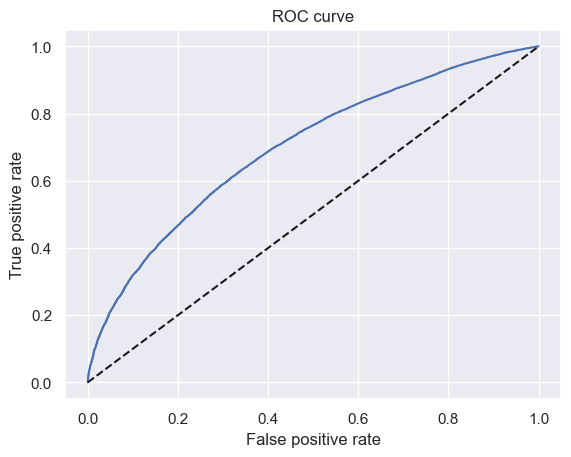

In [133]:
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [134]:
thresholds

array([       inf, 0.99243673, 0.98958921, ..., 0.49402799, 0.46761522,
       0.45301264], shape=(17370,))

In [135]:
thresholds.shape

(17370,)

In [136]:
df_cutoffs = pd.concat([pd.DataFrame(thresholds), pd.DataFrame(fpr), pd.DataFrame(tpr)], axis = 1)
# We concatenate 3 dataframes along the columns.

In [137]:
df_cutoffs.columns = ['thresholds', 'fpr', 'tpr']
# We name the columns of the dataframe 'thresholds', 'fpr', and 'tpr'.

In [138]:
df_cutoffs.head()

,thresholds,fpr,tpr
0,inf,0.000000,0.000000
1,0.992437,0.000000,0.000012
2,0.989589,0.000000,0.000457
3,0.989565,0.000098,0.000457
4,0.989485,0.000098,0.000506


In [139]:
#first row is not useful so

df_cutoffs['thresholds'][0] = 1 - 1 / np.power(10, 16)
# Let the first threshold (the value of the thresholds column with index 0) be equal to a number, very close to 1
# but smaller than 1, say 1 - 1 / 10 ^ 16.

Use the scores to calculate the cutoffs since they are interpretable

Score = log of odds, log of prob to be good - (1-prob to be good) - min sum of coefficients * ratio of diff of max and min score and diff of max sum of coeff and min sum of coeff + min socre 

In [140]:

df_cutoffs['Score'] = ((np.log(df_cutoffs['thresholds'] / (1 - df_cutoffs['thresholds'])) - min_sum_coef) * ((max_score - min_score) / (max_sum_coef - min_sum_coef)) + min_score).round()
# The score corresponsing to each threshold equals:
# The the difference between the natural logarithm of the ratio of the threshold and 1 minus the threshold and
# the minimum sum of coefficients
# multiplied by
# the sum of the minimum score and the ratio of the difference between the maximum score and minimum score and 
# the difference between the maximum sum of coefficients and the minimum sum of coefficients.

In [141]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,1.000000,0.000000,0.000000,3406.0
1,0.992437,0.000000,0.000012,790.0
2,0.989589,0.000000,0.000457,764.0
3,0.989565,0.000098,0.000457,763.0
4,0.989485,0.000098,0.000506,763.0


In [142]:
#place max score on row one 
df_cutoffs['Score'][0] = max_score

In [143]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,1.000000,0.000000,0.000000,850.0
1,0.992437,0.000000,0.000012,790.0
2,0.989589,0.000000,0.000457,764.0
3,0.989565,0.000098,0.000457,763.0
4,0.989485,0.000098,0.000506,763.0


In [144]:
df_cutoffs.tail()

,thresholds,fpr,tpr,Score
17365,0.512420,0.999313,0.999964,394.0
17366,0.509421,0.999313,0.999976,393.0
17367,0.494028,0.999804,0.999976,388.0
17368,0.467615,0.999804,1.000000,379.0
17369,0.453013,1.000000,1.000000,374.0


Approval rate and rejection rate for each possible cuttoff

1. use no of loan applications that will be approved
2. use the no of loan applications that will be rejected
3. No of applicants - the no in test dataset

In [146]:
# We define a function called 'n_approved' which assigns a value of 1 if a predicted probability
# is greater than the parameter p, which is a threshold, and a value of 0, if it is not.
# Then it sums the column.
# Thus, if given any percentage values, the function will return
# the number of rows wih estimated probabilites greater than the threshold. 
def n_approved(p):
    return np.where(df_actual_predicted_probs['y_hat_test_proba'] >= p, 1, 0).sum()

    # returns no of borrowers for which the predicted probability of default is >= p

In [147]:
df_cutoffs['N Approved'] = df_cutoffs['thresholds'].apply(n_approved)
# Assuming that all credit applications above a given probability of being 'good' will be approved,
# when we apply the 'n_approved' function to a threshold, it will return the number of approved applications.
# Thus, here we calculate the number of approved appliations for al thresholds.
df_cutoffs['N Rejected'] = df_actual_predicted_probs['y_hat_test_proba'].shape[0] - df_cutoffs['N Approved']
# Then, we calculate the number of rejected applications for each threshold.
# It is the difference between the total number of applications and the approved applications for that threshold.
df_cutoffs['Approval Rate'] = df_cutoffs['N Approved'] / df_actual_predicted_probs['y_hat_test_proba'].shape[0]
# Approval rate equalts the ratio of the approved applications and all applications.
df_cutoffs['Rejection Rate'] = 1 - df_cutoffs['Approval Rate']
# Rejection rate equals one minus approval rate.

In [148]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
0,1.000000,0.000000,0.000000,850.0,0,93257,0.000000,1.000000
1,0.992437,0.000000,0.000012,790.0,1,93256,0.000011,0.999989
2,0.989589,0.000000,0.000457,764.0,38,93219,0.000407,0.999593
3,0.989565,0.000098,0.000457,763.0,39,93218,0.000418,0.999582
4,0.989485,0.000098,0.000506,763.0,43,93214,0.000461,0.999539


In [149]:
df_cutoffs.tail()

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
17365,0.512420,0.999313,0.999964,394.0,93247,10,0.999893,0.000107
17366,0.509421,0.999313,0.999976,393.0,93248,9,0.999903,0.000097
17367,0.494028,0.999804,0.999976,388.0,93253,4,0.999957,0.000043
17368,0.467615,0.999804,1.000000,379.0,93255,2,0.999979,0.000021
17369,0.453013,1.000000,1.000000,374.0,93257,0,1.000000,0.000000


In [150]:
#asume the highest level of probability we'd accept is 10% - lowest prob of being good is 90%
df_cutoffs.iloc[5000: 6200, ]
# Here we display the dataframe with cutoffs form line with index 5000 to line with index 6200.

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
5000,0.904947,0.257799,0.541420,575.0,47600,45657,0.510417,0.489583
5001,0.904928,0.257799,0.541493,575.0,47606,45651,0.510482,0.489518
5002,0.904928,0.257897,0.541493,575.0,47607,45650,0.510493,0.489507
5003,0.904914,0.257897,0.541637,575.0,47619,45638,0.510621,0.489379
5004,0.904913,0.257995,0.541637,575.0,47620,45637,0.510632,0.489368
5005,0.904903,0.257995,0.541721,575.0,47627,45630,0.510707,0.489293
5006,0.904902,0.258093,0.541721,575.0,47628,45629,0.510718,0.489282
5007,0.904856,0.258093,0.541998,575.0,47651,45606,0.510964,0.489036
5008,0.904853,0.258191,0.541998,575.0,47652,45605,0.510975,0.489025
5009,0.904846,0.258191,0.542046,575.0,47656,45601,0.511018,0.488982


In [151]:
#at 5%
df_cutoffs.iloc[1000: 2000, ]
# Here we display the dataframe with cutoffs form line with index 1000 to line with index 2000.

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
1000,0.954022,0.048460,0.206626,639.0,17657,75600,0.189337,0.810663
1001,0.954022,0.048558,0.206626,639.0,17658,75599,0.189348,0.810652
1002,0.953859,0.048558,0.207818,638.0,17757,75500,0.190409,0.809591
1003,0.953856,0.048656,0.207818,638.0,17758,75499,0.190420,0.809580
1004,0.953813,0.048656,0.208071,638.0,17779,75478,0.190645,0.809355
1005,0.953808,0.048754,0.208071,638.0,17780,75477,0.190656,0.809344
1006,0.953777,0.048754,0.208348,638.0,17803,75454,0.190903,0.809097
1007,0.953772,0.048950,0.208348,638.0,17805,75452,0.190924,0.809076
1008,0.953736,0.048950,0.208661,638.0,17831,75426,0.191203,0.808797
1009,0.953735,0.049048,0.208661,638.0,17832,75425,0.191214,0.808786


In [152]:
inputs_train_with_ref_cat.to_csv('inputs_train_with_ref_cat.csv')

In [153]:
df_scorecard.to_csv('df_scorecard.csv')